In [1]:
import pandas as pd
import pickle as pkl
import os
import numpy as np
import itertools
import random

In [2]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

def get_gene_sent(g_id, cancer, n=10):
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent

In [3]:
gene2sent_map[0].keys()

dict_keys([2711, 13276, 885, 7967, 97, 808, 10820, 4660, 8637, 2687, 10965, 4339, 2996, 7212, 10867, 6517, 11951, 6467, 416, 3442, 6296, 3111, 8635, 11896, 897, 370, 12383, 8602, 1323, 6862, 10898, 5223, 1611, 9348, 10103, 11420, 3240, 10253, 11111, 12159, 6414, 12201, 13361, 1512, 12139, 12011, 3664, 3810, 1227, 7065, 10275, 10923, 8138, 3739, 12553, 1092, 6195, 2210, 4407, 4246, 10832, 392, 3293, 3708, 5775, 3524, 10163, 6594, 7950, 2526, 1481, 1910, 8837, 51, 5472, 3200, 1075, 9263, 7890, 6086, 7707, 7665, 10672, 1173, 3994, 4974, 9183, 2162, 8230, 9204, 1875, 7177, 9105, 804, 1703, 13377, 11205, 2094, 10939, 4580, 2219, 11680, 1861, 6601, 10853, 9728, 3030, 3804, 811, 2061, 9109, 3166, 477, 2924, 10486, 6691, 10512, 7428, 1582, 5258, 7375, 11926, 13162, 12384, 1757, 9132, 9890, 4859, 7774, 13169, 9673, 12174, 2283, 6894, 10591, 11390, 4542, 12795, 7003, 5503, 13337, 1233, 6068, 1663, 2865, 13252, 12389, 8166, 12506, 3632, 6372, 8497, 6421, 11438, 9568, 5100, 4837, 6345, 8208, 4496,

In [4]:
### 1. Determine the list of genes that we are comparing their co-expressed genes across contexts
### They should appear at least twice across all cancers

from collections import Counter

all_gene_ids = [list(gene2sent_map[i].keys()) for i in range(8)]
counts = Counter(i for ids in all_gene_ids for i in set(ids))
# Get genes appearing in at least 2 cancers
filt_gene_ids = [elem for elem, cnt in counts.items() if cnt >= 2]

len(filt_gene_ids)

12574

In [5]:
def compute_avg_jaccard(filt_gene_ids, sent_len=10, rand=False):
    ## sent_len shoud <= 200
    if rand:
        random.seed(0)
    jaccard_avg_allgenes = []
    for g_id in filt_gene_ids:
        co_exp_set = []
        for c in range(8):
            if g_id in gene2sent_map[c]:
                sent = gene2sent_map[c][g_id][:sent_len]
                sent = [i for i in sent if i != -1] ## remove paddings
                if len(sent) <= 2:
                    continue
                if rand:  ## make randomized sentence
                    sent_rdn = random.sample(filt_gene_ids, len(sent))
                    sent = sent_rdn
                co_exp_set.append(set(sent))
        
        ## average across each pairs of contexts
        jaccard_all = []
        for i,j in itertools.combinations(range(len(co_exp_set)), 2):
            set_i, set_j = co_exp_set[i], co_exp_set[j]
            jaccard = len(set_i & set_j) / len(set_i | set_j)
            jaccard_all.append(jaccard)
        
        jaccard_avg = np.mean(jaccard_all)
        jaccard_avg_allgenes.append(jaccard_avg)
    
    return jaccard_avg_allgenes

In [6]:
jaccard_avg_allgenes = compute_avg_jaccard(filt_gene_ids[:10], sent_len=10)

In [7]:
jaccard_avg_all_length = {}
for sent_len in [10,20,30,50,100,200]:
    jaccard_avg = compute_avg_jaccard(filt_gene_ids, sent_len=sent_len)
    jaccard_avg_all_length[sent_len] = jaccard_avg


In [33]:
## compute values for random sampled sentences
jaccard_avg_all_length_rdn = {}
for sent_len in [10,20,30,50,100,200]:
    jaccard_avg = compute_avg_jaccard(filt_gene_ids, sent_len=sent_len, rand=True)
    jaccard_avg_all_length_rdn[sent_len] = jaccard_avg

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:

def plot_boxplot(data):

    # Convert to tidy dataframe
    def dict_to_data(dict, label):
        df = pd.DataFrame([(k, v, label) for k, values in dict.items() for v in values],
                        columns=["Gene sentence length", "Avg. Jaccard similarity", "Group"])
        return df

    if len(data) > 1:   ## multiple data
        df_all = pd.concat([dict_to_data(v,k) for k,v in data.items()])
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_all, x="Gene sentence length", y="Avg. Jaccard similarity", hue="Group")
    else:
        label = list(data.keys())[0]
        data = data[label]
        df_all = pd.DataFrame([(k, v) for k, values in data.items() for v in values],
                        columns=["Gene sentence length", "Avg. Jaccard similarity"])
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_all, x="Gene sentence length", y="Avg. Jaccard similarity")
    
    plt.xlabel("Gene Sentence Length", fontsize=14)
    plt.ylabel("Avg. Jaccard Similarity", fontsize=14)
    plt.title("Avg. Jaccard similarity between co-expressed gene sets across cancer types")
    plt.show()


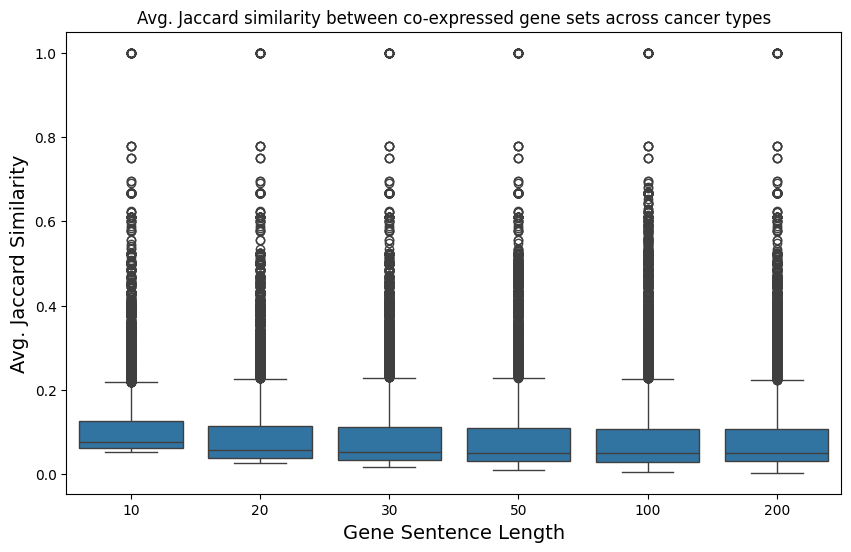

In [47]:
plot_boxplot({'original':jaccard_avg_all_length})

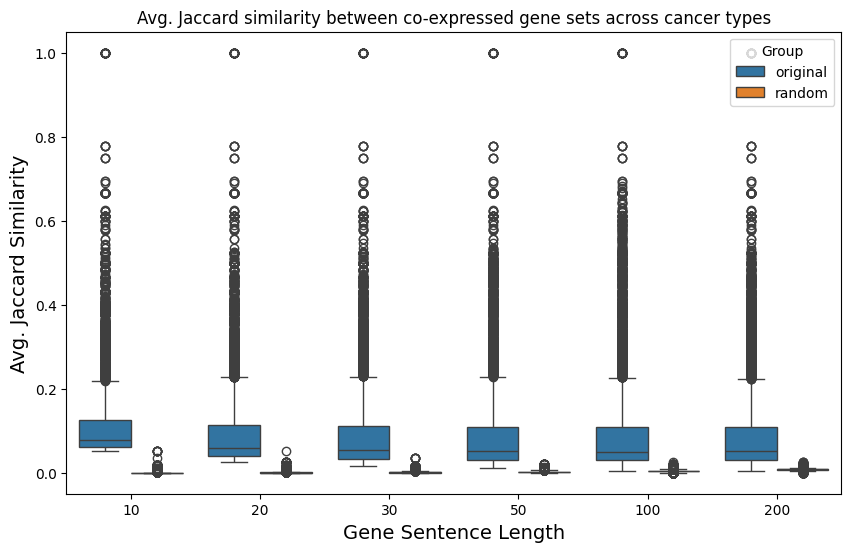

In [48]:
plot_boxplot({
    'original':jaccard_avg_all_length,
    'random': jaccard_avg_all_length_rdn})

In [18]:
def plot_violin(data):

    df_all = pd.DataFrame([(k, v) for k, values in data.items() for v in values],
                        columns=["Gene sentence length", "Avg. Jaccard similarity"])
    plt.figure(figsize=(10, 6), dpi=300)
    ax = sns.violinplot(
        x="Gene sentence length",
        y="Avg. Jaccard similarity",
        data=df_all,
        cut=0,
        inner="quart",        # shows quartile lines
        bw=0.3,
        linewidth=1,
        # color="#2ca02c",      # pick your color
    )

    # Clip the right half of each violin to make it one-sided
    for violin in ax.collections:
        path = violin.get_paths()[0]
        vertices = path.vertices
        mean_x = vertices[:, 0].mean()
        # vertices[:, 0] = np.minimum(vertices[:, 0], mean_x)
        vertices[:, 0] = np.maximum(vertices[:, 0], mean_x)

    plt.xlabel("Size of Co-expressed Gene Sets (used in Gene Sentences)", fontsize=14)
    plt.ylabel("Avg. Jaccard Similarity", fontsize=14)
    plt.title("Avg. Jaccard similarity between co-expressed gene sets across cancer types")
    plt.tight_layout()
    plt.show()
    

/tmp/ipykernel_3875055/4191159227.py:6: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


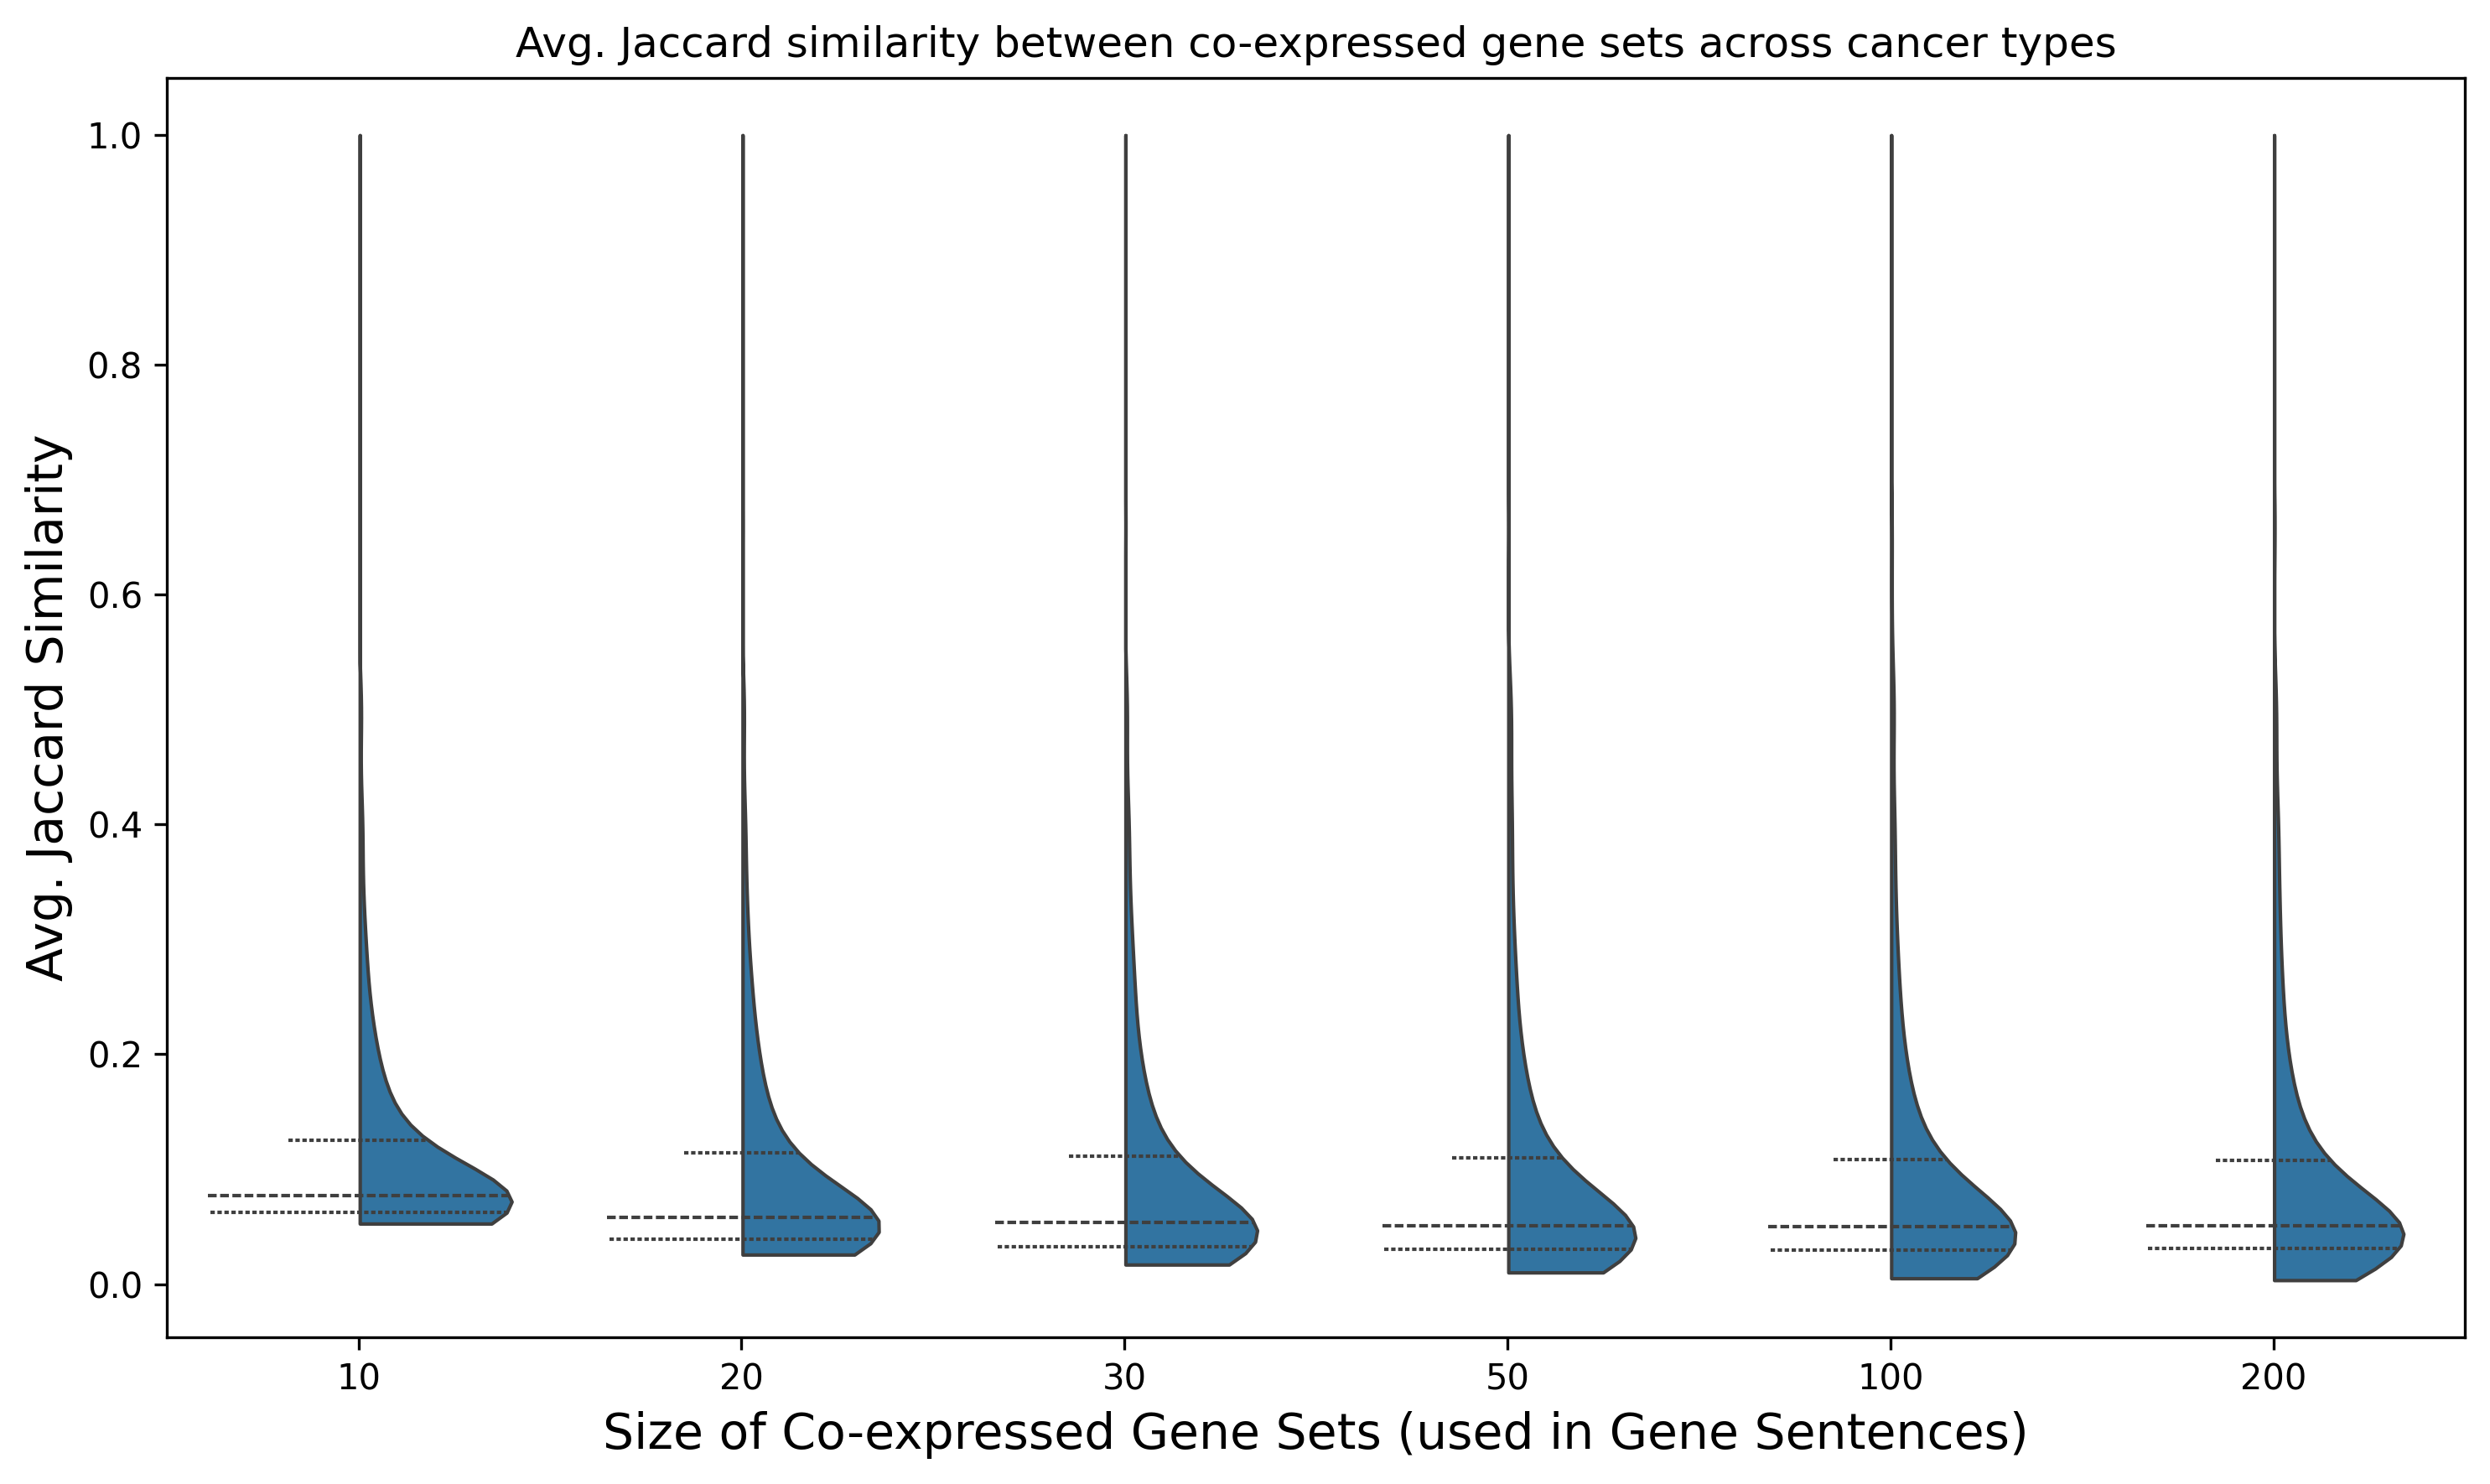

In [19]:
plot_violin(jaccard_avg_all_length)